# 01. Preprocessing & EDA: UCI Household Power Consumption

このノートブックでは、`UCI Individual Household Electric Power Consumption` データを対象に、予測モデルに入る前の **前処理** と **探索的データ分析（EDA）** を行う。

主な目的は以下の3点である。

1. `Date` と `Time` から時系列インデックスを作成する
2. 欠損値・重複時刻・時刻間隔を確認し、1分間隔の時系列として整える
3. `Global_active_power` とサブメータリング系列の周期性・分布・相関を確認する

このノートブックの出力は、後続の `02_statistical_time_series.ipynb`、`03_machine_learning_forecasting.ipynb`、`04_deep_learning_forecasting.ipynb`、`5_tda_feature_engineering_and_evaluation.ipynb` の前提データとして使う想定である。

## 0. 分析の準備

In [1]:
# 数値計算・データ処理
import numpy as np
import pandas as pd

# 可視化
from matplotlib import pyplot as plt
from matplotlib import dates as mdates

# パス操作
from pathlib import Path

# 表示設定
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. データの読み込み

元データはセミコロン区切りで、欠損値が `?` として含まれている。  
GitHub上では `data/household_power_consumption.txt` に配置する想定だが、ローカル実行時のためにカレントディレクトリ直下も探索する。

In [2]:
candidate_paths = [
    Path("../data/raw/household_power_consumption.txt"),
    Path("household_power_consumption.txt"),
    Path("/mnt/data/household_power_consumption.txt"),  # ChatGPT環境での確認用
]

file_path = next((p for p in candidate_paths if p.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "household_power_consumption.txt が見つかりません。"
        "data/ フォルダ、またはノートブックと同じ階層に配置してください。"
    )

print(f"読み込みファイル: {file_path}")

df_raw = pd.read_csv(
    file_path,
    sep=";",
    na_values=["?", "NA", "NaN", ""],
    low_memory=False,
)

print("データ形状:", df_raw.shape)
df_raw.head()

読み込みファイル: ..\data\raw\household_power_consumption.txt
データ形状: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 2. データの基本確認

In [3]:
print("列名")
print(df_raw.columns.tolist())

print("\nデータ型")
print(df_raw.dtypes)

print("\n基本統計量")
display(df_raw.describe(include="all"))

print("\n欠損値の個数")
display(df_raw.isna().sum().to_frame("missing_count"))

print("\n欠損率 [%]")
display((df_raw.isna().mean() * 100).to_frame("missing_rate_%"))

列名
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

データ型
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

基本統計量


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2075259,2075259,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
unique,1442,1440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,25/11/2010,17:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1440,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,NaN,NaN,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,NaN,NaN,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,NaN,NaN,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01



欠損値の個数


,missing_count
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979



欠損率 [%]


,missing_rate_%
Date,0.000000
Time,0.000000
Global_active_power,1.251844
Global_reactive_power,1.251844
Voltage,1.251844
Global_intensity,1.251844
Sub_metering_1,1.251844
Sub_metering_2,1.251844
Sub_metering_3,1.251844


## 3. 日時インデックスの作成

`Date` と `Time` を結合して `datetime` を作成し、時系列インデックスに設定する。  
UCIデータでは日付形式が `日/月/年` であるため、`format="%d/%m/%Y %H:%M:%S"` を明示する。

In [4]:
df = df_raw.copy()

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

# datetime に変換できなかった行を確認
print("datetime 変換失敗数:", df["datetime"].isna().sum())

# datetime を index にする
df = df.set_index("datetime").drop(columns=["Date", "Time"])

# 念のため時系列順に並べる
df = df.sort_index()

print("期間:", df.index.min(), "〜", df.index.max())
df.head()

datetime 変換失敗数: 0
期間: 2006-12-16 17:24:00 〜 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 4. 数値列への変換

In [5]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("変換後のデータ型")
print(df.dtypes)

print("\n変換後の欠損値")
display(df.isna().sum().to_frame("missing_count"))

変換後のデータ型
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

変換後の欠損値


,missing_count
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


## 5. 欠損値の確認と補間

時系列データなので、単純削除ではなく時間方向の線形補間を使う。  
ただし、補間前後の欠損状況を明示的に確認する。

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_rate_%": df.isna().mean() * 100,
})

display(missing_summary)

missing_rows = df[df.isna().any(axis=1)]
print("欠損を含む行数:", len(missing_rows))

display(missing_rows.head())
display(missing_rows.tail())

,missing_count,missing_rate_%
Global_active_power,25979,1.251844
Global_reactive_power,25979,1.251844
Voltage,25979,1.251844
Global_intensity,25979,1.251844
Sub_metering_1,25979,1.251844
Sub_metering_2,25979,1.251844
Sub_metering_3,25979,1.251844


欠損を含む行数: 25979


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-21 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-21 11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-30 10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-30 10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-14 18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2010-09-28 19:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:10:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:11:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09-28 19:12:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-10-24 15:35:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_clean = df.copy()

# 時系列方向に線形補間
df_clean = df_clean.interpolate(method="time")

# 先頭・末尾に欠損が残る場合に備える
df_clean = df_clean.ffill().bfill()

print("欠損値処理後の欠損数")
display(df_clean.isna().sum().to_frame("missing_count_after"))

欠損値処理後の欠損数


,missing_count_after
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


## 6. 時系列インデックスの確認

予測やリサンプリングでは、時系列順・重複なし・一定間隔であることが重要になる。

In [8]:
print("インデックスは時系列順か:", df_clean.index.is_monotonic_increasing)
print("重複時刻の数:", df_clean.index.duplicated().sum())

# 時刻間隔の確認
time_diff = df_clean.index.to_series().diff()
print("\n時刻間隔の上位")
display(time_diff.value_counts().head(10).to_frame("count"))

インデックスは時系列順か: True
重複時刻の数: 0

時刻間隔の上位


,count
datetime,
0 days 00:01:00,2075258


In [9]:
# 重複時刻がある場合は最初の値を採用する
df_clean = df_clean[~df_clean.index.duplicated(keep="first")]

# 1分間隔の時系列として明示的に整える
df_clean = df_clean.asfreq("1min")

# asfreq により発生した欠損を再度補間
df_clean = df_clean.interpolate(method="time").ffill().bfill()

print("整形後のデータ形状:", df_clean.shape)
print("整形後の期間:", df_clean.index.min(), "〜", df_clean.index.max())
print("整形後の欠損数:")
display(df_clean.isna().sum().to_frame("missing_count"))

整形後のデータ形状: (2075259, 7)
整形後の期間: 2006-12-16 17:24:00 〜 2010-11-26 21:02:00
整形後の欠損数:


,missing_count
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


## 7. 目的変数の確認

ここでは、家庭全体の有効電力消費量である `Global_active_power` を主な予測対象とする。

In [10]:
target_col = "Global_active_power"
y = df_clean[target_col]

print("目的変数の基本統計量")
display(y.describe().to_frame(target_col))

print("先頭")
display(y.head())

目的変数の基本統計量


,Global_active_power
count,2.075259e+06
mean,1.090280e+00
std,1.052628e+00
min,7.600000e-02
25%,3.100000e-01
50%,6.140000e-01
75%,1.528000e+00
max,1.112200e+01


先頭


datetime
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
Freq: min, Name: Global_active_power, dtype: float64

## 8. EDA: `Global_active_power` の推移

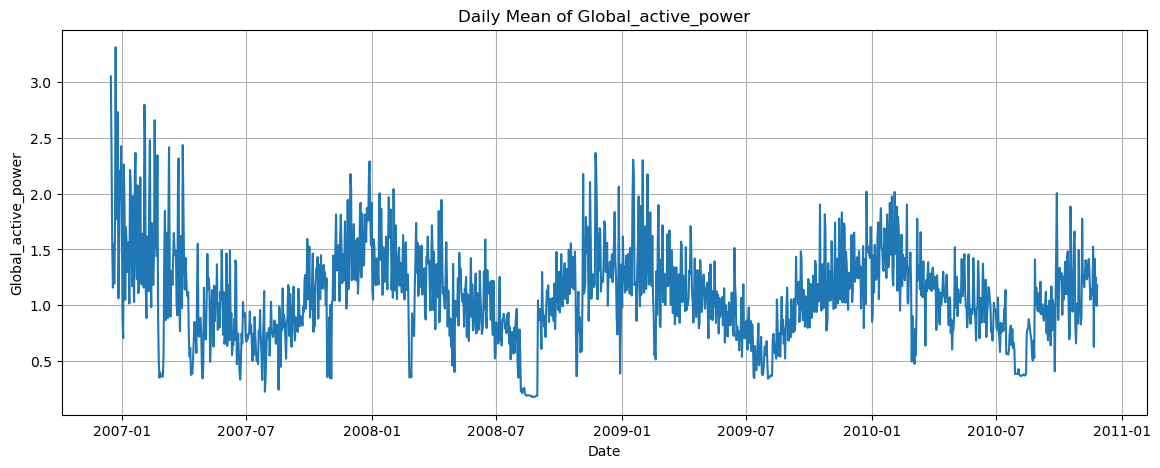

In [11]:
# 日次平均
y_daily = y.resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_daily.index, y_daily)
ax.set_title("Daily Mean of Global_active_power")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
plt.show()

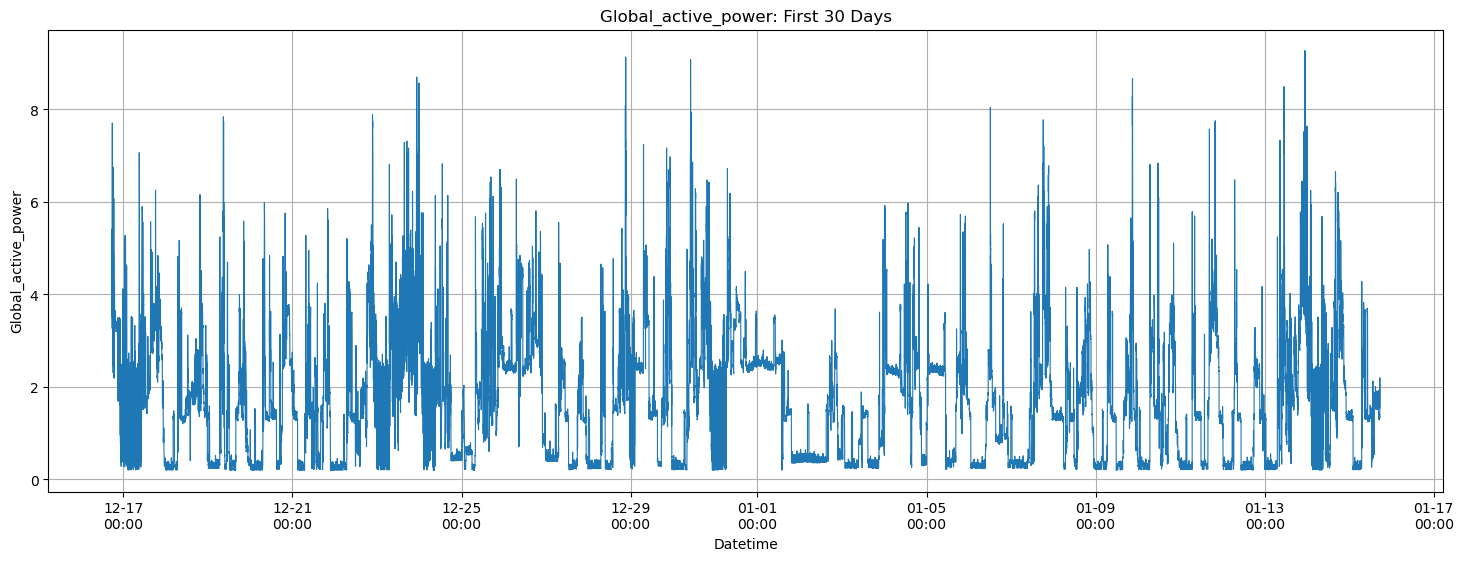

In [12]:
# 最初の30日間の分単位推移
first_month = y.loc[y.index.min() : y.index.min() + pd.Timedelta(days=30)]

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(first_month.index, first_month, linewidth=0.8)
ax.set_title("Global_active_power: First 30 Days")
ax.set_xlabel("Datetime")
ax.set_ylabel("Global_active_power")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.show()

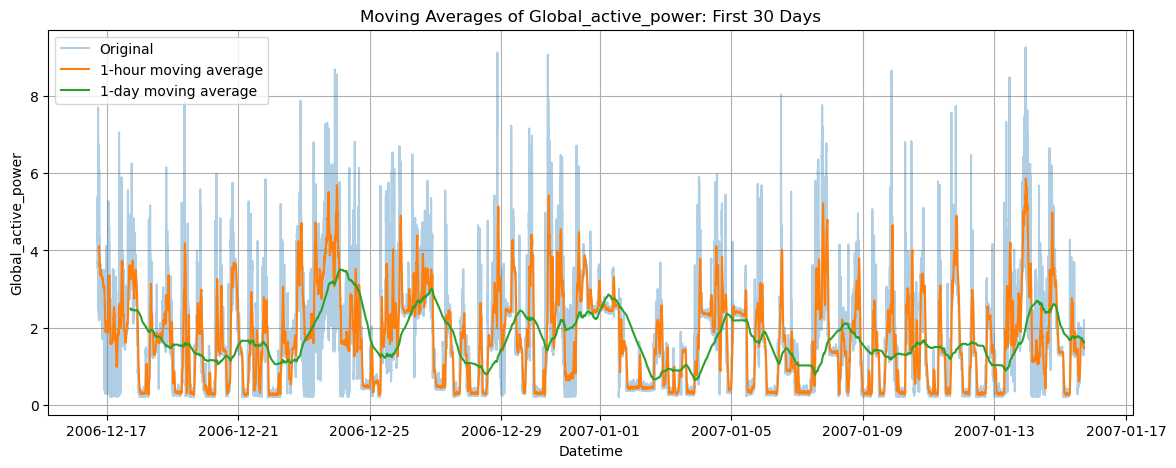

In [13]:
# 移動平均
plot_start = y.index.min()
plot_end = plot_start + pd.Timedelta(days=30)

y_hourly_ma = y.rolling(window=60).mean()       # 60分 = 1時間
y_daily_ma = y.rolling(window=60 * 24).mean()  # 1440分 = 1日

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y.loc[plot_start:plot_end], alpha=0.35, label="Original")
ax.plot(y_hourly_ma.loc[plot_start:plot_end], label="1-hour moving average")
ax.plot(y_daily_ma.loc[plot_start:plot_end], label="1-day moving average")
ax.set_title("Moving Averages of Global_active_power: First 30 Days")
ax.set_xlabel("Datetime")
ax.set_ylabel("Global_active_power")
ax.legend()
plt.show()

## 9. EDA: 周期性の確認

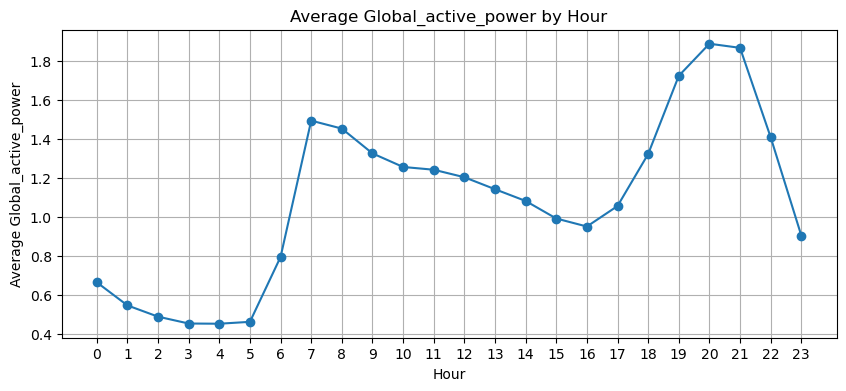

datetime,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
hourly_mean,0.663418,0.544698,0.486809,0.451589,0.450522,0.46022,0.793647,1.494386,1.453509,1.326026,1.256255,1.24212,1.203516,1.141929,1.081551,0.991351,0.950159,1.055458,1.322805,1.724749,1.889776,1.868581,1.40879,0.903677


In [14]:
# 時刻ごとの平均使用量
hourly_pattern = y.groupby(y.index.hour).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_pattern.index, hourly_pattern, marker="o")
ax.set_title("Average Global_active_power by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Average Global_active_power")
ax.set_xticks(range(24))
plt.show()

display(hourly_pattern.to_frame("hourly_mean").T)

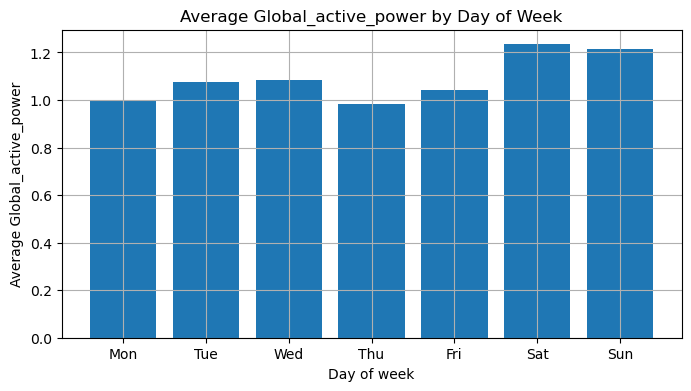

,weekday,mean
0,Mon,1.001749
1,Tue,1.074770
2,Wed,1.085026
3,Thu,0.982072
4,Fri,1.042086
5,Sat,1.233651
6,Sun,1.213079


In [15]:
# 曜日ごとの平均使用量
weekday_pattern = y.groupby(y.index.dayofweek).mean()
weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(weekday_labels, weekday_pattern)
ax.set_title("Average Global_active_power by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average Global_active_power")
plt.show()

display(pd.DataFrame({"weekday": weekday_labels, "mean": weekday_pattern.values}))

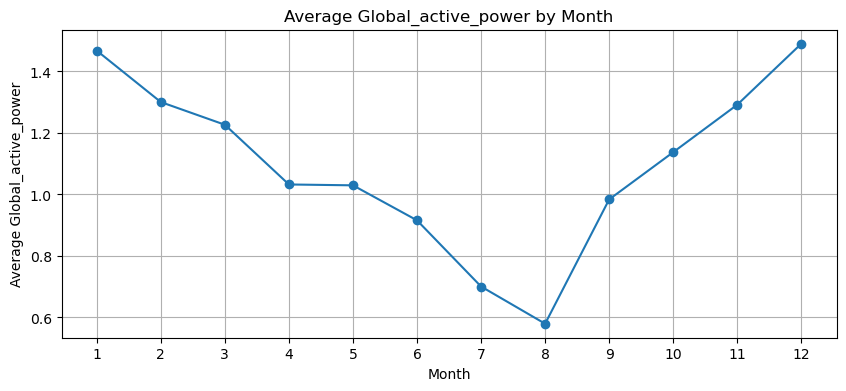

,monthly_mean
datetime,
1,1.467443
2,1.300329
3,1.226522
4,1.032375
5,1.029572
6,0.915760
7,0.700603
8,0.579623
9,0.983779


In [16]:
# 月ごとの平均使用量
monthly_pattern = y.groupby(y.index.month).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_pattern.index, monthly_pattern, marker="o")
ax.set_title("Average Global_active_power by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Global_active_power")
ax.set_xticks(range(1, 13))
plt.show()

display(monthly_pattern.to_frame("monthly_mean"))

## 10. EDA: 日次統計量・サブメータリング

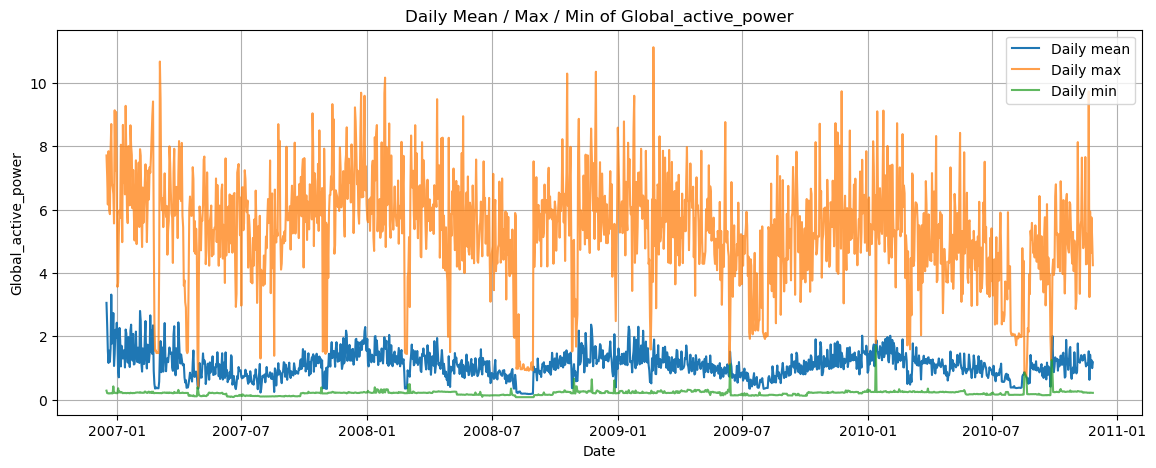

,mean,max,min
datetime,,,
2006-12-16,3.053475,7.706,0.284
2006-12-17,2.354486,7.064,0.206
2006-12-18,1.530435,6.158,0.202
2006-12-19,1.157079,7.840,0.194
2006-12-20,1.545658,5.988,0.202


In [17]:
daily_summary = pd.DataFrame({
    "mean": y.resample("D").mean(),
    "max": y.resample("D").max(),
    "min": y.resample("D").min(),
})

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_summary.index, daily_summary["mean"], label="Daily mean")
ax.plot(daily_summary.index, daily_summary["max"], label="Daily max", alpha=0.75)
ax.plot(daily_summary.index, daily_summary["min"], label="Daily min", alpha=0.75)
ax.set_title("Daily Mean / Max / Min of Global_active_power")
ax.set_xlabel("Date")
ax.set_ylabel("Global_active_power")
ax.legend()
plt.show()

display(daily_summary.head())

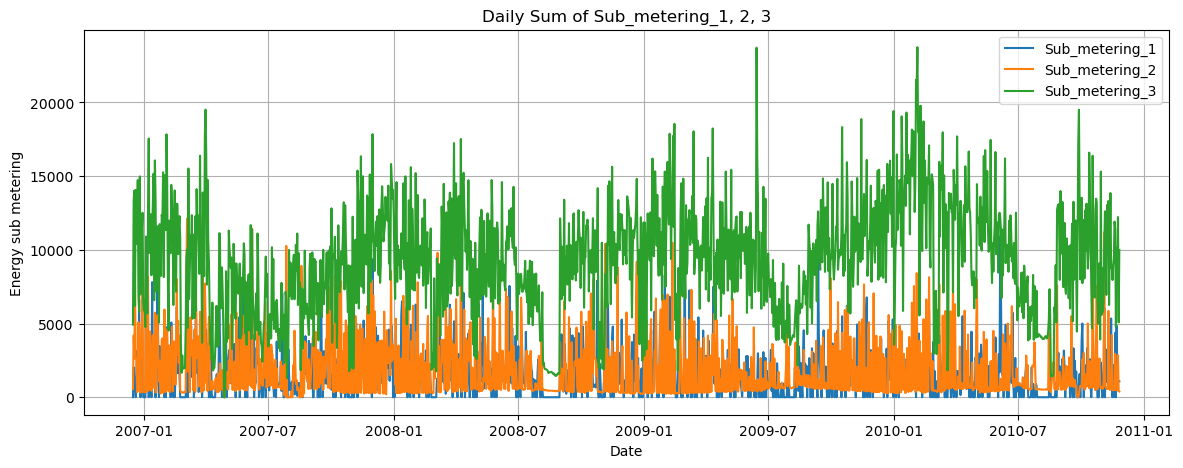

,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,
2006-12-16,0.0,546.0,4926.0
2006-12-17,2033.0,4187.0,13341.0
2006-12-18,1063.0,2621.0,14018.0
2006-12-19,839.0,7602.0,6197.0
2006-12-20,0.0,2648.0,14063.0


In [18]:
sub_cols = ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
sub_daily = df_clean[sub_cols].resample("D").sum()

fig, ax = plt.subplots(figsize=(14, 5))
for col in sub_cols:
    ax.plot(sub_daily.index, sub_daily[col], label=col)
ax.set_title("Daily Sum of Sub_metering_1, 2, 3")
ax.set_xlabel("Date")
ax.set_ylabel("Energy sub metering")
ax.legend()
plt.show()

display(sub_daily.head())

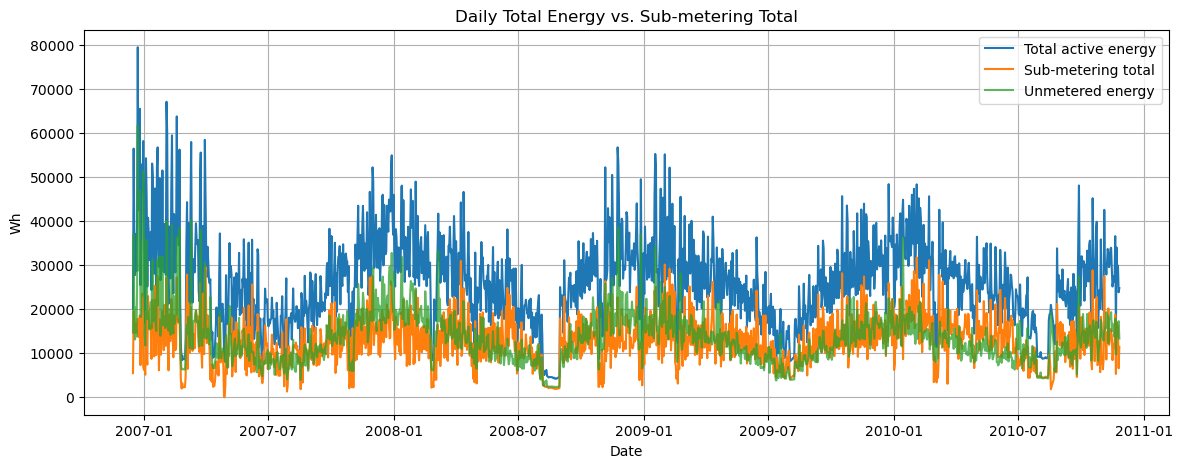

,global_active_energy_wh,sub_metering_total,unmetered_wh
datetime,,,
2006-12-16,20152.933333,5472.0,14680.933333
2006-12-17,56507.666667,19561.0,36946.666667
2006-12-18,36730.433333,17702.0,19028.433333
2006-12-19,27769.900000,14638.0,13131.900000
2006-12-20,37095.800000,16711.0,20384.800000


In [19]:
# Global_active_power は kW なので、1分間の消費電力量 Wh に変換する
# kW * 1000 / 60 = Wh per minute

df_vis = df_clean.copy()
df_vis["global_active_energy_wh"] = df_vis["Global_active_power"] * 1000 / 60

df_vis["sub_metering_total"] = (
    df_vis["Sub_metering_1"]
    + df_vis["Sub_metering_2"]
    + df_vis["Sub_metering_3"]
)

energy_daily = df_vis[["global_active_energy_wh", "sub_metering_total"]].resample("D").sum()
energy_daily["unmetered_wh"] = energy_daily["global_active_energy_wh"] - energy_daily["sub_metering_total"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(energy_daily.index, energy_daily["global_active_energy_wh"], label="Total active energy")
ax.plot(energy_daily.index, energy_daily["sub_metering_total"], label="Sub-metering total")
ax.plot(energy_daily.index, energy_daily["unmetered_wh"], label="Unmetered energy", alpha=0.75)
ax.set_title("Daily Total Energy vs. Sub-metering Total")
ax.set_xlabel("Date")
ax.set_ylabel("Wh")
ax.legend()
plt.show()

display(energy_daily.head())

## 11. EDA: 相関・分布・外れ値候補

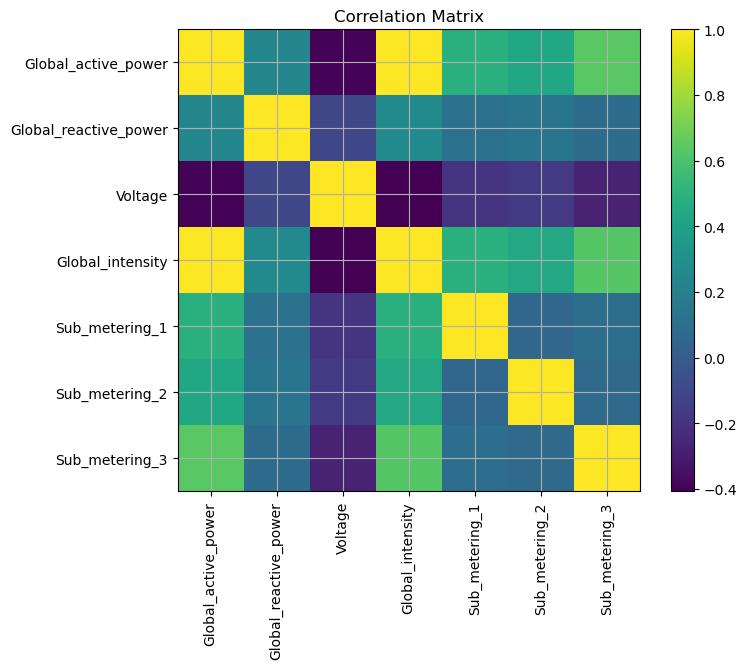

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.245047,-0.395522,0.998887,0.483816,0.433892,0.639272
Global_reactive_power,0.245047,1.000000,-0.109030,0.264162,0.122743,0.139204,0.087743
Voltage,-0.395522,-0.109030,1.000000,-0.407198,-0.194100,-0.165348,-0.265510
Global_intensity,0.998887,0.264162,-0.407198,1.000000,0.488756,0.439713,0.627264
Sub_metering_1,0.483816,0.122743,-0.194100,0.488756,1.000000,0.055011,0.102704
Sub_metering_2,0.433892,0.139204,-0.165348,0.439713,0.055011,1.000000,0.080710
Sub_metering_3,0.639272,0.087743,-0.265510,0.627264,0.102704,0.080710,1.000000


In [20]:
corr = df_clean.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
ax.set_title("Correlation Matrix")
plt.show()

display(corr)

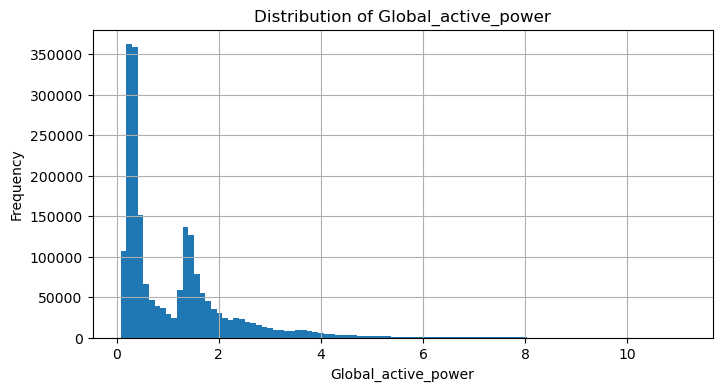

,value
q_0.95,3.246
q_0.99,4.838
q_0.999,6.780
max,11.122


In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y.dropna(), bins=100)
ax.set_title("Distribution of Global_active_power")
ax.set_xlabel("Global_active_power")
ax.set_ylabel("Frequency")
plt.show()

quantile_summary = pd.Series({
    "q_0.95": y.quantile(0.95),
    "q_0.99": y.quantile(0.99),
    "q_0.999": y.quantile(0.999),
    "max": y.max(),
})

display(quantile_summary.to_frame("value"))

In [22]:
# 上位0.1%を外れ値候補として確認する
threshold = y.quantile(0.999)
high_usage = df_clean.loc[y >= threshold].copy()

print("上位0.1%しきい値:", threshold)
print("高使用量候補の件数:", len(high_usage))

display(high_usage.head())
display(high_usage.tail())

上位0.1%しきい値: 6.78
高使用量候補の件数: 2078


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:45:00,7.706,0.000,230.98,33.2,0.0,0.0,17.0
2006-12-16 17:46:00,7.026,0.000,232.21,30.6,0.0,0.0,16.0
2006-12-17 09:03:00,7.064,0.124,235.57,30.0,0.0,37.0,0.0
2006-12-17 09:04:00,6.926,0.118,235.35,29.4,0.0,37.0,0.0
2006-12-19 08:47:00,7.828,0.182,232.20,33.6,36.0,72.0,17.0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2010-11-20 18:26:00,9.694,0.066,226.05,42.8,43.0,67.0,16.0
2010-11-20 18:27:00,8.600,0.090,226.94,38.2,44.0,51.0,16.0
2010-11-20 18:28:00,6.882,0.186,229.77,30.4,30.0,35.0,16.0
2010-11-20 18:31:00,6.830,0.394,229.39,30.2,24.0,34.0,16.0
2010-11-20 18:35:00,6.784,0.364,228.38,30.0,21.0,35.0,16.0


## 12. TDAを見据えた多変量時系列の確認

後続ノートブックでTDA特徴量を追加する場合、`Global_active_power` だけでなく、電圧・電流・サブメータリングを含む多変量系列として扱う可能性がある。  
ここでは、TDA候補変数を日次平均に集約して概形を確認する。

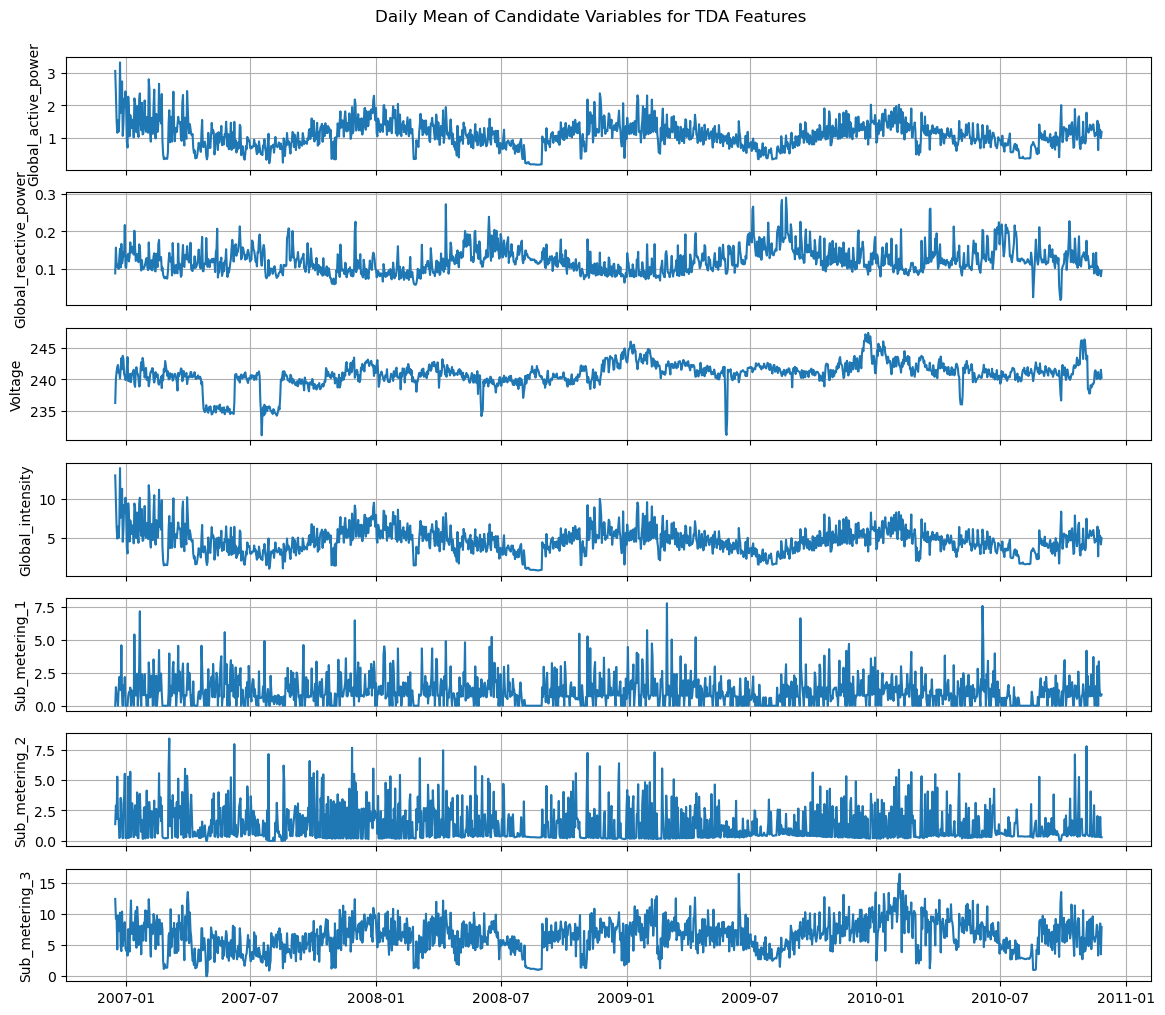

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972


In [23]:
tda_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

df_tda_daily = df_clean[tda_cols].resample("D").mean()

fig, axes = plt.subplots(len(tda_cols), 1, figsize=(14, 12), sharex=True)

for ax, col in zip(axes, tda_cols):
    ax.plot(df_tda_daily.index, df_tda_daily[col])
    ax.set_ylabel(col)

fig.suptitle("Daily Mean of Candidate Variables for TDA Features", y=0.92)
plt.show()

display(df_tda_daily.head())

## 13. 前処理済みデータの保存

後続ノートブックで再利用しやすいように、以下を保存する。

- 1分間隔に整えた前処理済みデータ
- 日次平均データ
- TDA候補変数の日次平均データ

GitHubでは `data/processed/` に保存する想定である。

In [24]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# 1分間隔データは大きいため csv.gz で保存する
df_clean.to_csv(processed_dir / "household_power_consumption_clean_1min.csv.gz", compression="gzip")



daily_df = df_clean.resample("D").mean()
daily_df.to_csv(processed_dir / "household_power_consumption_daily_mean.csv")

df_tda_daily.to_csv(processed_dir / "household_power_consumption_tda_daily_mean.csv")

print("保存完了")
print(processed_dir / "household_power_consumption_clean_1min.csv.gz")
print(processed_dir / "household_power_consumption_daily_mean.csv")
print(processed_dir / "household_power_consumption_tda_daily_mean.csv")

保存完了
..\data\processed\household_power_consumption_clean_1min.csv.gz
..\data\processed\household_power_consumption_daily_mean.csv
..\data\processed\household_power_consumption_tda_daily_mean.csv


## 14. 考察

### データ品質

- 元データには欠損値が含まれているため、時系列方向の線形補間で処理した。
- `Date` と `Time` を結合し、1分間隔の `DatetimeIndex` として整備した。
- 重複時刻がある場合は先頭を採用し、`asfreq("1min")` により時刻間隔を明示的に統一した。

### `Global_active_power` の特徴

- 分単位では短時間のスパイクが多く、ノイズの大きい系列である。
- 日次平均に集約すると、長期的な水準変化や季節性が確認しやすくなる。
- 時刻別平均から、生活リズムに由来する日内周期が見られる。
- 月別平均から、季節性を考慮する必要がある。

### 後続分析への方針

- 統計モデルでは、まず日次平均の `Global_active_power` を対象にする。
- 機械学習では、ラグ特徴量、移動平均、曜日・月などのカレンダー特徴量を作成する。
- TDA特徴量では、分単位または時間単位の局所的な波形構造を sliding window embedding により特徴量化する。

このノートブックは、モデル構築ではなく、後続の予測・TDA実装に入るための土台として位置づける。